<a href="https://colab.research.google.com/github/JuanMuneton87/Fund_Ciencia_de_Datos/blob/main/proyecto_aula/py_Juan_Diego_Muneton_Herrera_Proyecto_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from wordcloud import WordCloud
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)
from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer
from scipy.stats import zscore
from sklearn.cluster import KMeans

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{\r\n  "username": "JuanHerrera1987",\r\n  "key": "KGAT_753893a9829fba323aa31ab5358df39f"\r\n}'}

In [ ]:
# Configurar Kaggle
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Descargar dataset
!kaggle datasets download -d ggtejas/tmdb-imdb-merged-movies-dataset

# Descomprimir
!unzip tmdb-imdb-merged-movies-dataset.zip

# Cargar dataset
df = pd.read_csv('TMDB  IMDB Movies Dataset.csv')
df.head()

Dataset URL: https://www.kaggle.com/datasets/ggtejas/tmdb-imdb-merged-movies-dataset
License(s): CC-BY-NC-SA-4.0
tmdb-imdb-merged-movies-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  tmdb-imdb-merged-movies-dataset.zip
replace TMDB  IMDB Movies Dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: TMDB  IMDB Movies Dataset.csv  


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,genres,production_companies,production_countries,spoken_languages,keywords,directors,writers,averageRating,numVotes,cast
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",Christopher Nolan,Christopher Nolan,8.8,2822508,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan",8.7,2539015,"Matthew McConaughey, Anne Hathaway, Michael Ca..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Go...",9.1,3174396,"Christian Bale, Heath Ledger, Aaron Eckhart, M..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",James Cameron,James Cameron,7.9,1500052,"Sam Worthington, Zoe Saldaña, Sigourney Weaver..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",Joss Whedon,"Joss Whedon, Zak Penn",8.0,1560470,"Robert Downey Jr., Chris Evans, Mark Ruffalo, ..."


In [ ]:
df_original = df.copy()

In [ ]:
muestra_presentacion = (
    df[
        [
            'title',
            'budget',
            'revenue',
            'popularity',
            'vote_average',
            'averageRating',
            'runtime'
        ]
    ]
    .describe()
    .round(2)
)

display(muestra_presentacion)

,budget,revenue,popularity,vote_average,averageRating,runtime
count,4.385210e+05,4.385210e+05,438521.00,438521.00,438521.00,438521.0
mean,6.494878e+05,1.660454e+06,2.18,3.59,6.22,66.4
std,7.409256e+06,2.619276e+07,11.31,3.15,1.31,64.2
min,0.000000e+00,0.000000e+00,0.00,0.00,1.00,0.0
25%,0.000000e+00,0.000000e+00,0.60,0.00,5.40,15.0
50%,0.000000e+00,0.000000e+00,0.85,4.50,6.30,80.0
75%,0.000000e+00,0.000000e+00,1.65,6.20,7.10,96.0
max,8.880000e+08,2.923706e+09,2994.36,10.00,10.00,14400.0


In [ ]:
top_runtime = (
    df[
        ['title', 'runtime', 'budget', 'revenue']
    ]
    .sort_values(
        by='runtime',
        ascending=True
    )
    .head(10)
    .reset_index(drop=True)
)

top_runtime.index = top_runtime.index + 1
top_runtime.index.name = 'Ranking'

top_runtime.rename(
    columns={
        'title': 'Película',
        'runtime': 'Duración (min)'
    },
    inplace=True
)

top_runtime

,Película,Duración (min),budget,revenue
Ranking,,,,
1,Black Art Collection -Testimony-,0,0,0
2,Delírio em Las Vedras,0,0,0
3,Valomanden,0,0,0
4,Manic Lover,0,8000,0
5,Splattenstein 2000,0,0,0
6,Emesis Blue,0,0,0
7,Emesis Blue,0,0,0
8,Emesis Blue,0,0,0
9,Classic Albums: Simply Red - Stars,0,0,0


In [ ]:
print(f"Número de películas: {df.shape[0]:,}")
print(f"Número de variables: {df.shape[1]}")

Número de películas: 438,521
Número de variables: 29


#PREGUNTA

¿Cómo se relacionan el presupuesto, la popularidad y las valoraciones de las películas con sus ingresos en taquilla?

Variable objetivo: revenue.

Variables explicativas: budget, popularity, vote_average, vote_count.

Variables complementarias: directors, cast, original_language, release_year, runtime, main_genre.

#Exploración inicial del dataset

In [ ]:
# Dimensiones del dataset
df.shape

(438521, 29)

In [ ]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438521 entries, 0 to 438520
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    438521 non-null  int64  
 1   title                 438521 non-null  object 
 2   vote_average          438521 non-null  float64
 3   vote_count            438521 non-null  int64  
 4   status                438521 non-null  object 
 5   release_date          416017 non-null  object 
 6   revenue               438521 non-null  int64  
 7   runtime               438521 non-null  int64  
 8   adult                 438521 non-null  bool   
 9   backdrop_path         185765 non-null  object 
 10  budget                438521 non-null  int64  
 11  homepage              54942 non-null   object 
 12  tconst                438521 non-null  object 
 13  original_language     438521 non-null  object 
 14  original_title        438521 non-null  object 
 15  

In [ ]:
#Resumen estadístico del dataset
df.describe()

,id,vote_average,vote_count,revenue,runtime,budget,popularity,averageRating,numVotes
count,4.385210e+05,438521.000000,438521.000000,4.385210e+05,438521.000000,4.385210e+05,438521.000000,438521.000000,4.385210e+05
mean,4.986961e+05,3.585166,48.599153,1.660454e+06,66.401652,6.494878e+05,2.183474,6.220964,3.139806e+03
std,3.704997e+05,3.152712,511.377126,2.619276e+07,64.201779,7.409256e+06,11.313994,1.310995,3.417257e+04
min,2.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000,5.000000e+00
25%,2.112770e+05,0.000000,0.000000,0.000000e+00,15.000000,0.000000e+00,0.600000,5.400000,2.300000e+01
50%,4.212940e+05,4.500000,1.000000,0.000000e+00,80.000000,0.000000e+00,0.849000,6.300000,7.000000e+01
75%,7.169860e+05,6.200000,5.000000,0.000000e+00,96.000000,0.000000e+00,1.649000,7.100000,3.280000e+02
max,1.708589e+06,10.000000,34495.000000,2.923706e+09,14400.000000,8.880000e+08,2994.357000,10.000000,3.193679e+06


In [ ]:
#Identificar valores nulos
df.isnull().sum().sort_values(ascending=False)

,0
homepage,383579
tagline,345869
keywords,267602
backdrop_path,252756
production_companies,176195
production_countries,117471
spoken_languages,105929
genres,80884
poster_path,76885
cast,69060


In [ ]:
# Filtrar registros con
# valores financieros válidos
df = df[
    (df['budget'] >= 1000) &
    (df['revenue'] >= 1000)
]

In [ ]:
#Filtrar duración de películas
df = df[
    (df['runtime'] >= 60)
]

In [ ]:
# Eliminar duplicados según el nombre
# de la película
df = df.drop_duplicates(
    subset='title',
    keep='first'
)

In [ ]:
#Conversión de fechas y extracción del año
df['release_date'] = pd.to_datetime(
    df['release_date'],
    errors='coerce'
)

df['release_year'] = (
    df['release_date']
    .dt.year
)

In [ ]:
#Evaluación de asimetría
variables_numericas = [
    'budget',
    'revenue',
    'popularity',
    'vote_average',
    'averageRating',
    'runtime'
]

for col in variables_numericas:
    print(f"{col}: {df[col].skew():.2f}")

budget: 3.26
revenue: 5.75
popularity: 28.37
vote_average: -2.16
averageRating: -0.78
runtime: 4.02


In [ ]:
df.describe()

,id,vote_average,vote_count,release_date,revenue,runtime,budget,popularity,averageRating,numVotes,release_year
count,9.394000e+03,9394.000000,9394.000000,9380,9.394000e+03,9394.000000,9.394000e+03,9394.000000,9394.000000,9.394000e+03,9380.000000
mean,1.489906e+05,6.272555,1600.697254,2001-06-14 08:16:10.234541568,6.948851e+07,109.735469,2.469342e+07,20.036614,6.364307,9.945630e+04,2000.920362
min,5.000000e+00,0.000000,0.000000,1913-11-24 00:00:00,1.000000e+03,60.000000,1.000000e+03,0.000000,1.100000,7.000000e+00,1913.000000
25%,1.053550e+04,5.800000,84.000000,1994-11-18 00:00:00,2.400000e+06,94.000000,2.734475e+06,7.467000,5.700000,6.070000e+03,1994.000000
50%,3.402600e+04,6.417000,449.500000,2006-09-30 12:00:00,1.470096e+07,105.000000,1.000000e+07,13.454500,6.500000,2.812250e+04,2006.000000
75%,2.445592e+05,7.006000,1634.750000,2014-01-22 12:00:00,6.278393e+07,120.000000,3.000000e+07,20.967000,7.100000,1.031490e+05,2014.000000
max,1.668134e+06,10.000000,34495.000000,2023-10-01 00:00:00,2.923706e+09,720.000000,4.600000e+08,2994.357000,9.600000,3.193679e+06,2023.000000
std,2.185989e+05,1.309256,3045.932404,NaN,1.590199e+08,23.843098,3.852952e+07,63.294699,1.104261,2.030535e+05,18.537299


In [ ]:
# Verificar dimensiones
df.shape

(9394, 30)

In [ ]:
df_clean = df.copy()

In [ ]:
muestra_presentacion = (
    df_clean[
        [
            'title',
            'budget',
            'revenue',
            'popularity',
            'vote_average',
            'averageRating',
            'runtime'
        ]
    ]
    .describe()
    .round(2)
)

display(muestra_presentacion)

,budget,revenue,popularity,vote_average,averageRating,runtime
count,9.394000e+03,9.394000e+03,9394.00,9394.00,9394.00,9394.00
mean,2.469342e+07,6.948851e+07,20.04,6.27,6.36,109.74
std,3.852952e+07,1.590199e+08,63.29,1.31,1.10,23.84
min,1.000000e+03,1.000000e+03,0.00,0.00,1.10,60.00
25%,2.734475e+06,2.400000e+06,7.47,5.80,5.70,94.00
50%,1.000000e+07,1.470096e+07,13.45,6.42,6.50,105.00
75%,3.000000e+07,6.278393e+07,20.97,7.01,7.10,120.00
max,4.600000e+08,2.923706e+09,2994.36,10.00,9.60,720.00


In [ ]:
top_runtime = (
    df_clean[
        ['title', 'runtime', 'budget', 'revenue']
    ]
    .sort_values(
        by='runtime',
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

top_runtime.index = top_runtime.index + 1
top_runtime.index.name = 'Ranking'

top_runtime.rename(
    columns={
        'title': 'Película',
        'runtime': 'Duración (min)'
    },
    inplace=True
)

top_runtime

,Película,Duración (min),budget,revenue
Ranking,,,,
1,Arcane,720,250000000,108000000
2,Utopia,622,14000000,36000000
3,Carlos,339,18000000,871279
4,River of Fundament,310,5000000,44840
5,Eric Clapton's Crossroads Guitar Festival 2010,279,100000,1000000
6,Downey's Dream Cars,270,250000,400000
7,Gettysburg,254,25000000,12700000
8,Cleopatra,248,44000000,71000000
9,UFC 94: St-Pierre vs. Penn 2,241,1091000,4290020


In [ ]:
print(f"Número de películas: {df_clean.shape[0]:,}")
print(f"Número de variables: {df_clean.shape[1]}")

Número de películas: 9,394
Número de variables: 30


In [ ]:
#Identificar valores nulos
df_clean.isnull().sum().sort_values(ascending=False)

,0
homepage,6240
tagline,1790
keywords,883
backdrop_path,450
production_companies,291
production_countries,169
writers,115
spoken_languages,62
poster_path,54
genres,29


In [ ]:
# Información general
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9394 entries, 0 to 438193
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    9394 non-null   int64         
 1   title                 9394 non-null   object        
 2   vote_average          9394 non-null   float64       
 3   vote_count            9394 non-null   int64         
 4   status                9394 non-null   object        
 5   release_date          9380 non-null   datetime64[ns]
 6   revenue               9394 non-null   int64         
 7   runtime               9394 non-null   int64         
 8   adult                 9394 non-null   bool          
 9   backdrop_path         8944 non-null   object        
 10  budget                9394 non-null   int64         
 11  homepage              3154 non-null   object        
 12  tconst                9394 non-null   object        
 13  original_language    

Algunas variables textuales presentan una alta proporción de valores faltantes, particularmente homepage, tagline y keywords, lo cual limita su utilidad analítica dentro del estudio principal.

Se observó una alta proporción de registros con valores muy bajos (menores a 1000) en las variables budget y revenue. Debido a que estos valores pueden corresponder a información no reportada o incompleta, se construyó un subconjunto de datos con registros financieros válidos para realizar los análisis relacionados con desempeño económico.

Se filtraron valores extremos en la variable runtime debido a la presencia de duraciones poco representativas para películas comerciales, lo que podría afectar la interpretación estadística y visual de los datos.

#Primeras visualizaciones

#Correlaciones

In [ ]:
#Matriz de correlación
corr = df_clean[
    [
        'budget',
        'revenue',
        'popularity',
        'vote_average',
        'averageRating'
    ]
].corr()

corr

,budget,revenue,popularity,vote_average,averageRating
budget,1.000000,0.740771,0.235302,0.116511,0.060000
revenue,0.740771,1.000000,0.225068,0.181292,0.175664
popularity,0.235302,0.225068,1.000000,0.114888,0.053301
vote_average,0.116511,0.181292,0.114888,1.000000,0.610747
averageRating,0.060000,0.175664,0.053301,0.610747,1.000000


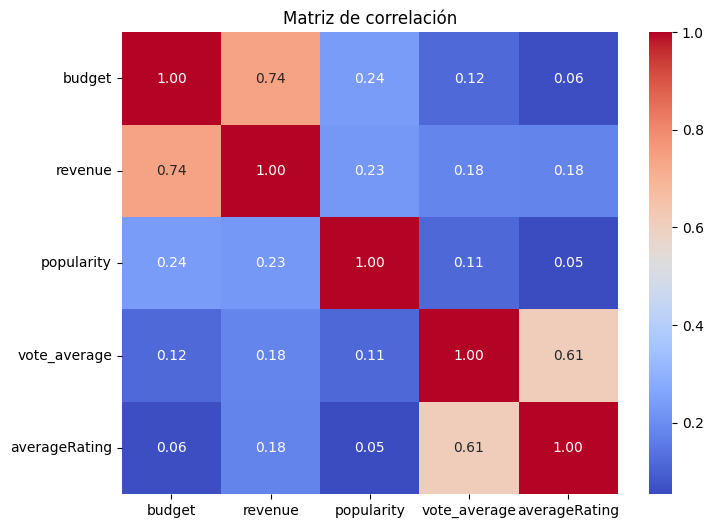

In [ ]:
#Visualización de correlaciones
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de correlación')

plt.show()

#Histogramas

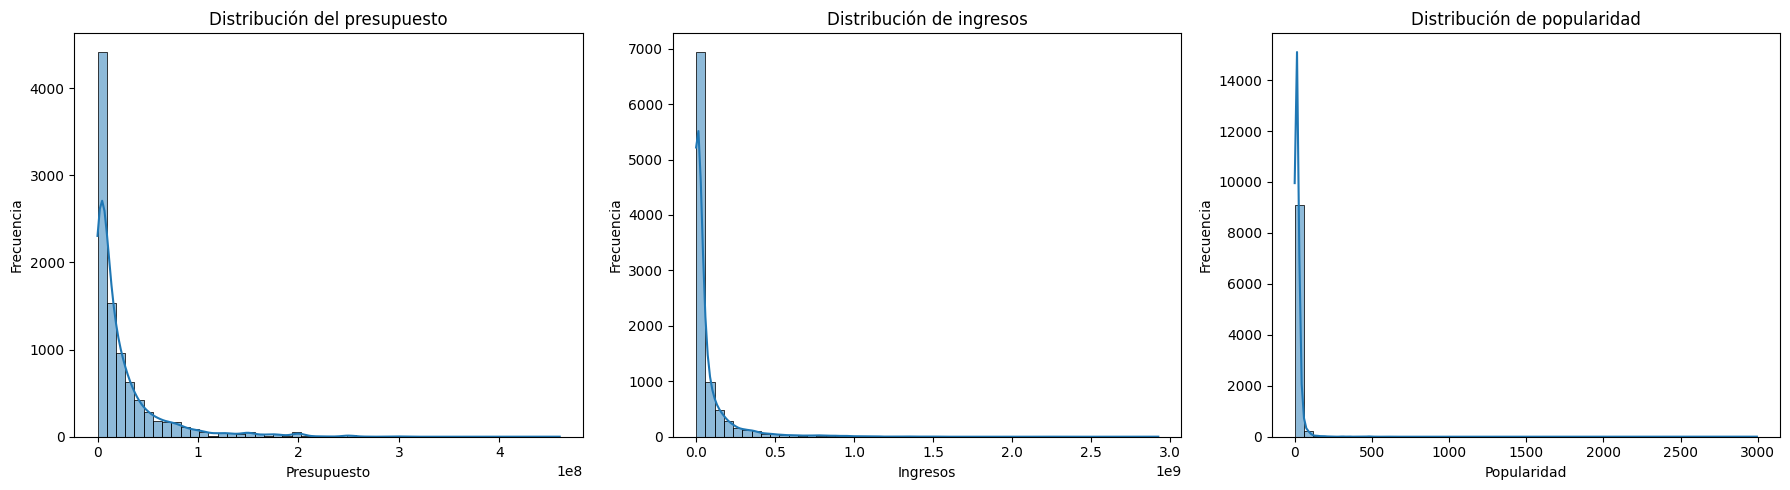

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Histograma Budget
sns.histplot(
    df_clean['budget'],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title('Distribución del presupuesto')
axes[0].set_xlabel('Presupuesto')
axes[0].set_ylabel('Frecuencia')

# Histograma Revenue
sns.histplot(
    df_clean['revenue'],
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title('Distribución de ingresos')
axes[1].set_xlabel('Ingresos')
axes[1].set_ylabel('Frecuencia')

# Histograma Popularity
sns.histplot(
    df_clean['popularity'],
    bins=50,
    kde=True,
    ax=axes[2]
)

axes[2].set_title('Distribución de popularidad')
axes[2].set_xlabel('Popularidad')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()

plt.show()

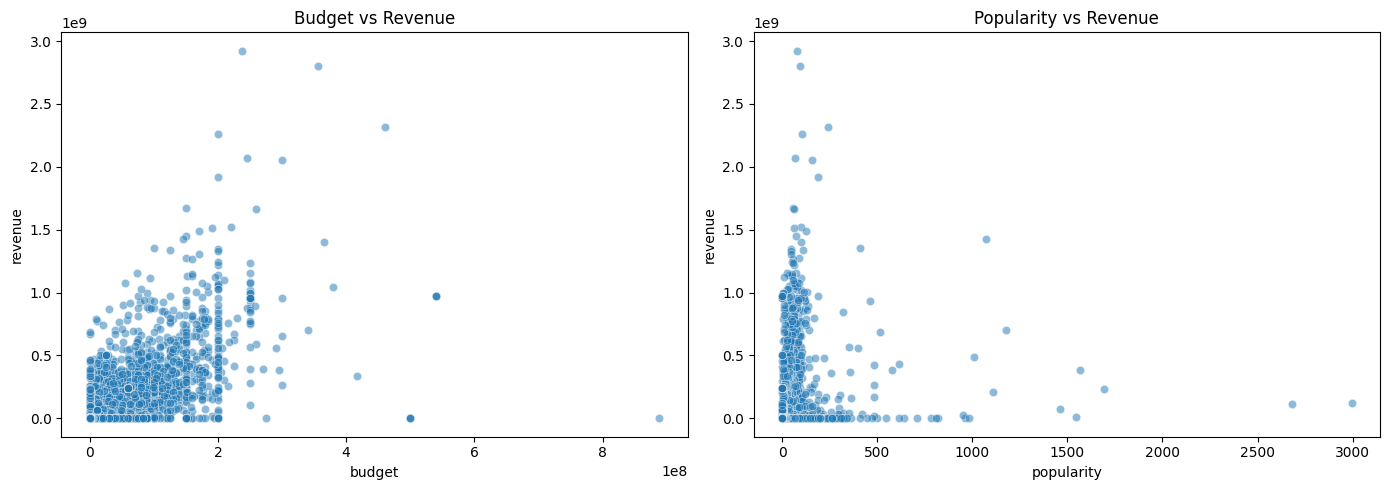

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Budget vs Revenue
sns.scatterplot(
    data=df_original,
    x='budget',
    y='revenue',
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title('Budget vs Revenue')

# Popularity vs Revenue
sns.scatterplot(
    data=df_original,
    x='popularity',
    y='revenue',
    alpha=0.5,
    ax=axes[1]
)

axes[1].set_title('Popularity vs Revenue')

plt.tight_layout()

plt.show()

#Estadísticas descriptivas

In [ ]:
#Construcción de tabla estadística descriptiva
variables = [
    'budget',
    'revenue',
    'popularity',
    'vote_average',
    'averageRating',
    'runtime'
]

tabla_estadistica = pd.DataFrame()

for col in variables:

    tabla_estadistica.loc[col, 'Media'] = df_clean[col].mean()

    tabla_estadistica.loc[col, 'Mediana'] = df_clean[col].median()

    tabla_estadistica.loc[col, 'Desv_Std'] = df_clean[col].std()

    tabla_estadistica.loc[col, 'Varianza'] = df_clean[col].var()

    tabla_estadistica.loc[col, 'Min'] = df_clean[col].min()

    tabla_estadistica.loc[col, 'Max'] = df_clean[col].max()

    tabla_estadistica.loc[col, 'Rango'] = (
        df_clean[col].max() - df_clean[col].min()
    )

    tabla_estadistica.loc[col, 'Q1_25%'] = (
        df_clean[col].quantile(0.25)
    )

    tabla_estadistica.loc[col, 'Q2_50%'] = (
        df_clean[col].quantile(0.50)
    )

    tabla_estadistica.loc[col, 'Q3_75%'] = (
        df_clean[col].quantile(0.75)
    )

    tabla_estadistica.loc[col, 'P90'] = (
        df_clean[col].quantile(0.90)
    )

    tabla_estadistica.loc[col, 'P95'] = (
        df_clean[col].quantile(0.95)
    )

    tabla_estadistica.loc[col, 'IQR'] = (
        df_clean[col].quantile(0.75)
        -
        df_clean[col].quantile(0.25)
    )

    tabla_estadistica.loc[col, 'Skewness'] = (
        df_clean[col].skew()
    )

    tabla_estadistica.loc[col, 'Kurtosis'] = (
        df_clean[col].kurt()
    )

# Redondear resultados
tabla_estadistica = tabla_estadistica.round(2)

tabla_estadistica

,Media,Mediana,Desv_Std,Varianza,Min,Max,Rango,Q1_25%,Q2_50%,Q3_75%,P90,P95,IQR,Skewness,Kurtosis
budget,24693424.17,10000000.00,3.852952e+07,1.484524e+15,1000.0,4.600000e+08,4.599990e+08,2734475.00,10000000.00,30000000.00,6.500000e+07,1.000000e+08,27265525.00,3.26,14.58
revenue,69488510.55,14700959.00,1.590199e+08,2.528731e+16,1000.0,2.923706e+09,2.923705e+09,2400000.00,14700959.00,62783928.25,1.808210e+08,3.217675e+08,60383928.25,5.75,52.84
popularity,20.04,13.45,6.329000e+01,4.006220e+03,0.0,2.994360e+03,2.994360e+03,7.47,13.45,20.97,3.434000e+01,4.794000e+01,13.50,28.37,1048.97
vote_average,6.27,6.42,1.310000e+00,1.710000e+00,0.0,1.000000e+01,1.000000e+01,5.80,6.42,7.01,7.500000e+00,7.800000e+00,1.21,-2.16,8.69
averageRating,6.36,6.50,1.100000e+00,1.220000e+00,1.1,9.600000e+00,8.500000e+00,5.70,6.50,7.10,7.600000e+00,8.000000e+00,1.40,-0.78,1.33
runtime,109.74,105.00,2.384000e+01,5.684900e+02,60.0,7.200000e+02,6.600000e+02,94.00,105.00,120.00,1.390000e+02,1.523500e+02,26.00,4.02,71.33


La correlación entre budget y revenue fue de 0.74, evidenciando que las películas con mayores presupuestos tienden a generar mayores ingresos en taquilla, aunque esto no implica causalidad directa.

Por otro lado, popularity y revenue presentan una correlación positiva baja (0.23), lo que indica que una mayor popularidad puede asociarse con mayores ingresos, pero existen otros factores relevantes en el desempeño comercial. Asimismo, la relación entre las valoraciones promedio y los ingresos es positiva pero débil, sugiriendo que una mejor recepción del público no garantiza necesariamente mayores ganancias.

Finalmente, vote_average y averageRating muestran una correlación moderada positiva (0.56), reflejando cierta consistencia entre las valoraciones registradas en TMDB e IMDb.

El análisis evidencia una fuerte concentración del éxito comercial en la industria cinematográfica, donde unas pocas películas acumulan presupuestos, ingresos y niveles de popularidad excepcionalmente altos, mientras la mayoría presenta valores considerablemente menores. Esto explica la alta asimetría y la presencia de valores extremos en las variables financieras y de popularidad.

En contraste, las variables de valoración y duración muestran comportamientos más estables y homogéneos, lo que sugiere que la percepción del público y la duración de las películas tienden a mantenerse dentro de rangos más consistentes.

La presencia de valores extremos en las variable revenue, budget y popularity, causan un sesgo positivo y distribuciones no normales. Lo que justifica la creación de versiones logarítmicas de estas variables.

In [ ]:
#Transformación logarítmica
df_clean['log_budget'] = np.log1p(df_clean['budget'])

df_clean['log_revenue'] = np.log1p(df_clean['revenue'])

df_clean['log_popularity'] = np.log1p(df_clean['popularity'])

In [ ]:
#Evaluación de asimetría
variables_log = [
    'log_budget',
    'log_revenue',
    'log_popularity'
]

for col in variables_log:
    print(f"{col}: {df_clean[col].skew():.2f}")

log_budget: -1.15
log_revenue: -0.80
log_popularity: -0.10


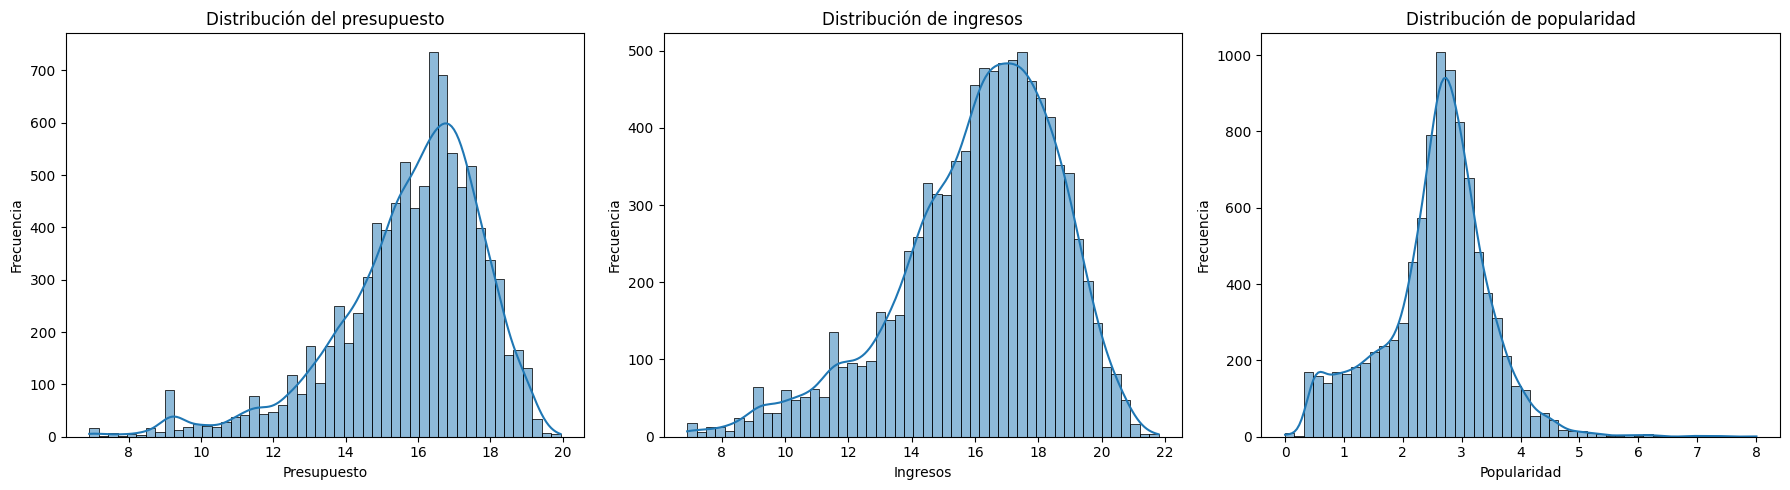

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Histograma Budget
sns.histplot(
    df_clean['log_budget'],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title('Distribución del presupuesto')
axes[0].set_xlabel('Presupuesto')
axes[0].set_ylabel('Frecuencia')

# Histograma Revenue
sns.histplot(
    df_clean['log_revenue'],
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title('Distribución de ingresos')
axes[1].set_xlabel('Ingresos')
axes[1].set_ylabel('Frecuencia')

# Histograma Popularity
sns.histplot(
    df_clean['log_popularity'],
    bins=50,
    kde=True,
    ax=axes[2]
)

axes[2].set_title('Distribución de popularidad')
axes[2].set_xlabel('Popularidad')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()

plt.show()

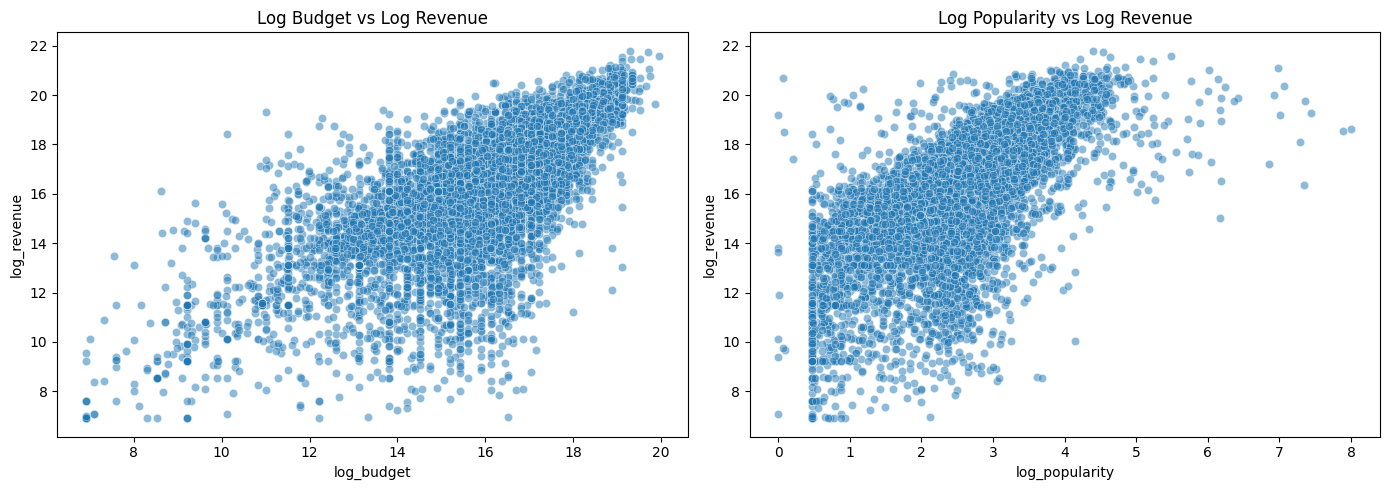

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Budget vs Revenue
sns.scatterplot(
    data=df_clean,
    x='log_budget',
    y='log_revenue',
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title('Log Budget vs Log Revenue')

# Popularity vs Revenue
sns.scatterplot(
    data=df_clean,
    x='log_popularity',
    y='log_revenue',
    alpha=0.5,
    ax=axes[1]
)

axes[1].set_title('Log Popularity vs Log Revenue')

plt.tight_layout()

plt.show()

Las transformaciones logarítmicas redujeron significativamente la asimetría y el impacto de los valores extremos en las variables financieras y de popularidad, evidenciando que gran parte de la variabilidad inicial estaba concentrada en unas pocas películas con resultados excepcionalmente altos. Esto permitió obtener distribuciones más estables y adecuadas para análisis posteriores.

A partir de los scatterplots, se observa además que el presupuesto mantiene una relación más consistente con los ingresos en taquilla, lo que sugiere que una mayor inversión suele asociarse con mejores resultados comerciales. En contraste, la popularidad presenta una relación más débil y dispersa, indicando que no explica por sí sola el éxito financiero de una película.

In [ ]:
variables_escalado = [
    'budget',
    'revenue',
    'popularity'
]

# Copia de trabajo
df_scaling = df_clean.copy()

# Inicializar escaladores
standard_scaler = StandardScaler()

minmax_scaler = MinMaxScaler()

robust_scaler = RobustScaler()

# Aplicar transformaciones
df_scaling_std = pd.DataFrame(
    standard_scaler.fit_transform(
        df_scaling[variables_escalado]
    ),
    columns=[
        f'{col}_std'
        for col in variables_escalado
    ]
)

df_scaling_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(
        df_scaling[variables_escalado]
    ),
    columns=[
        f'{col}_minmax'
        for col in variables_escalado
    ]
)

df_scaling_robust = pd.DataFrame(
    robust_scaler.fit_transform(
        df_scaling[variables_escalado]
    ),
    columns=[
        f'{col}_robust'
        for col in variables_escalado
    ]
)

# Unir resultados
df_scaling = pd.concat(
    [
        df_scaling.reset_index(drop=True),
        df_scaling_std,
        df_scaling_minmax,
        df_scaling_robust
    ],
    axis=1
)

df_scaling.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,log_popularity,budget_std,revenue_std,popularity_std,budget_minmax,revenue_minmax,popularity_minmax,budget_robust,revenue_robust,popularity_robust
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,4.442086,3.511951,4.754655,1.009860,0.347825,0.282358,0.028037,5.501453,13.427941,5.222037
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,4.950468,3.641728,3.976072,1.899224,0.358694,0.240013,0.046835,5.684835,11.377667,9.391593
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,4.880094,4.160838,5.880522,1.747576,0.402173,0.343591,0.043630,6.418362,16.392731,8.680630
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,4.393609,5.510525,17.949768,0.946344,0.515216,1.000000,0.026694,8.325532,48.175154,4.924259
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,4.595948,5.069281,9.114611,1.233113,0.478260,0.519483,0.032756,7.702034,24.909187,6.268704


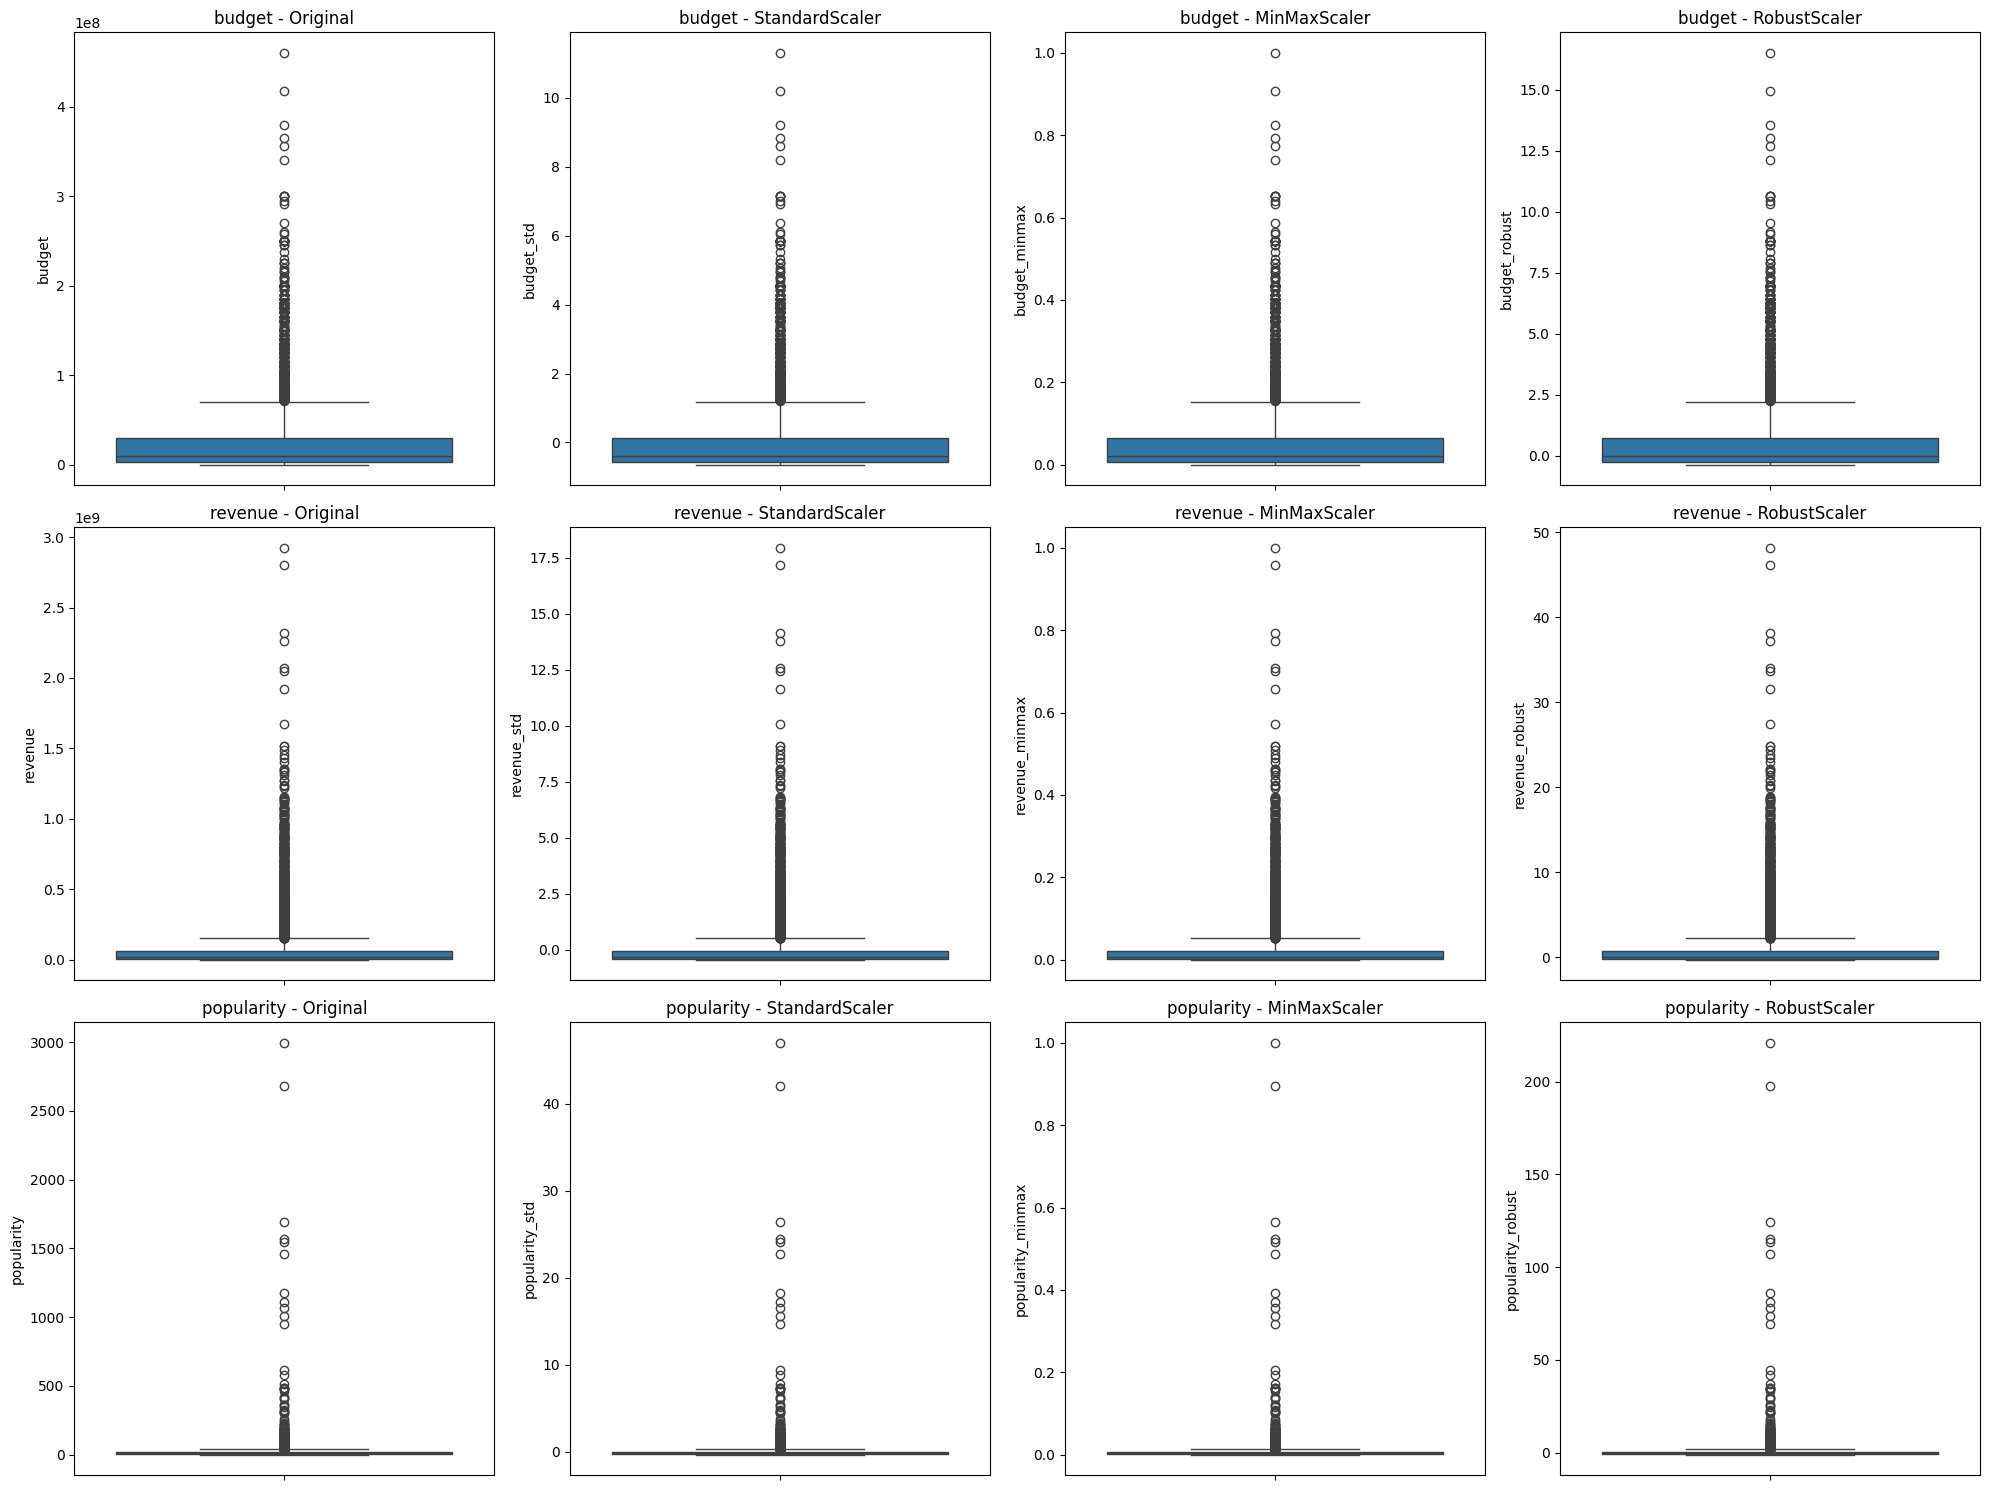

In [ ]:
#Comparación de métodos de escalamiento
variables = [
    'budget',
    'revenue',
    'popularity'
]

transformaciones = [
    '',
    '_std',
    '_minmax',
    '_robust'
]

titulos = [
    'Original',
    'StandardScaler',
    'MinMaxScaler',
    'RobustScaler'
]

fig, axes = plt.subplots(
    3,
    4,
    figsize=(20,15)
)

for i, var in enumerate(variables):

    for j, trans in enumerate(transformaciones):

        columna = f'{var}{trans}'

        sns.boxplot(
            y=df_scaling[columna],
            ax=axes[i,j]
        )

        axes[i,j].set_title(
            f'{var} - {titulos[j]}'
        )

plt.tight_layout()

plt.show()

In [ ]:
# Tabla comparativa de métodos de escalamiento
variables = [
    'budget',
    'revenue',
    'popularity'
]

transformaciones = [
    '',
    '_std',
    '_minmax',
    '_robust'
]

tabla_scaling = pd.DataFrame()

for var in variables:

    for trans in transformaciones:

        columna = f'{var}{trans}'

        nombre = (
            f'{var}{trans}'
            if trans != ''
            else f'{var}_original'
        )

        tabla_scaling.loc[nombre, 'Media'] = (
            df_scaling[columna].mean()
        )

        tabla_scaling.loc[nombre, 'Desv_Std'] = (
            df_scaling[columna].std()
        )

        tabla_scaling.loc[nombre, 'Min'] = (
            df_scaling[columna].min()
        )

        tabla_scaling.loc[nombre, 'Max'] = (
            df_scaling[columna].max()
        )

tabla_scaling = tabla_scaling.round(2)

tabla_scaling

,Media,Desv_Std,Min,Max
budget_original,24693424.17,3.852952e+07,1000.00,4.600000e+08
budget_std,0.00,1.000000e+00,-0.64,1.130000e+01
budget_minmax,0.05,8.000000e-02,0.00,1.000000e+00
budget_robust,0.54,1.410000e+00,-0.37,1.650000e+01
revenue_original,69488510.55,1.590199e+08,1000.00,2.923706e+09
revenue_std,-0.00,1.000000e+00,-0.44,1.795000e+01
revenue_minmax,0.02,5.000000e-02,0.00,1.000000e+00
revenue_robust,0.91,2.630000e+00,-0.24,4.818000e+01
popularity_original,20.04,6.329000e+01,0.00,2.994360e+03
popularity_std,0.00,1.000000e+00,-0.32,4.699000e+01


In [ ]:
# Copia de trabajo
df_transform = df_clean.copy()

variables_transformar = [
    'budget',
    'revenue',
    'popularity'
]

# Inicializar Yeo-Johnson
pt = PowerTransformer(
    method='yeo-johnson'
)

for col in variables_transformar:

    # LOG
    df_transform[f'{col}_log'] = np.log1p(
        df_transform[col]
    )

    # BOX-COX
    df_transform[f'{col}_boxcox'], _ = boxcox(
        df_transform[col] + 1
    )

    # YEO-JOHNSON
    df_transform[f'{col}_yeojohnson'] = (
        pt.fit_transform(
            df_transform[[col]]
        )
    )

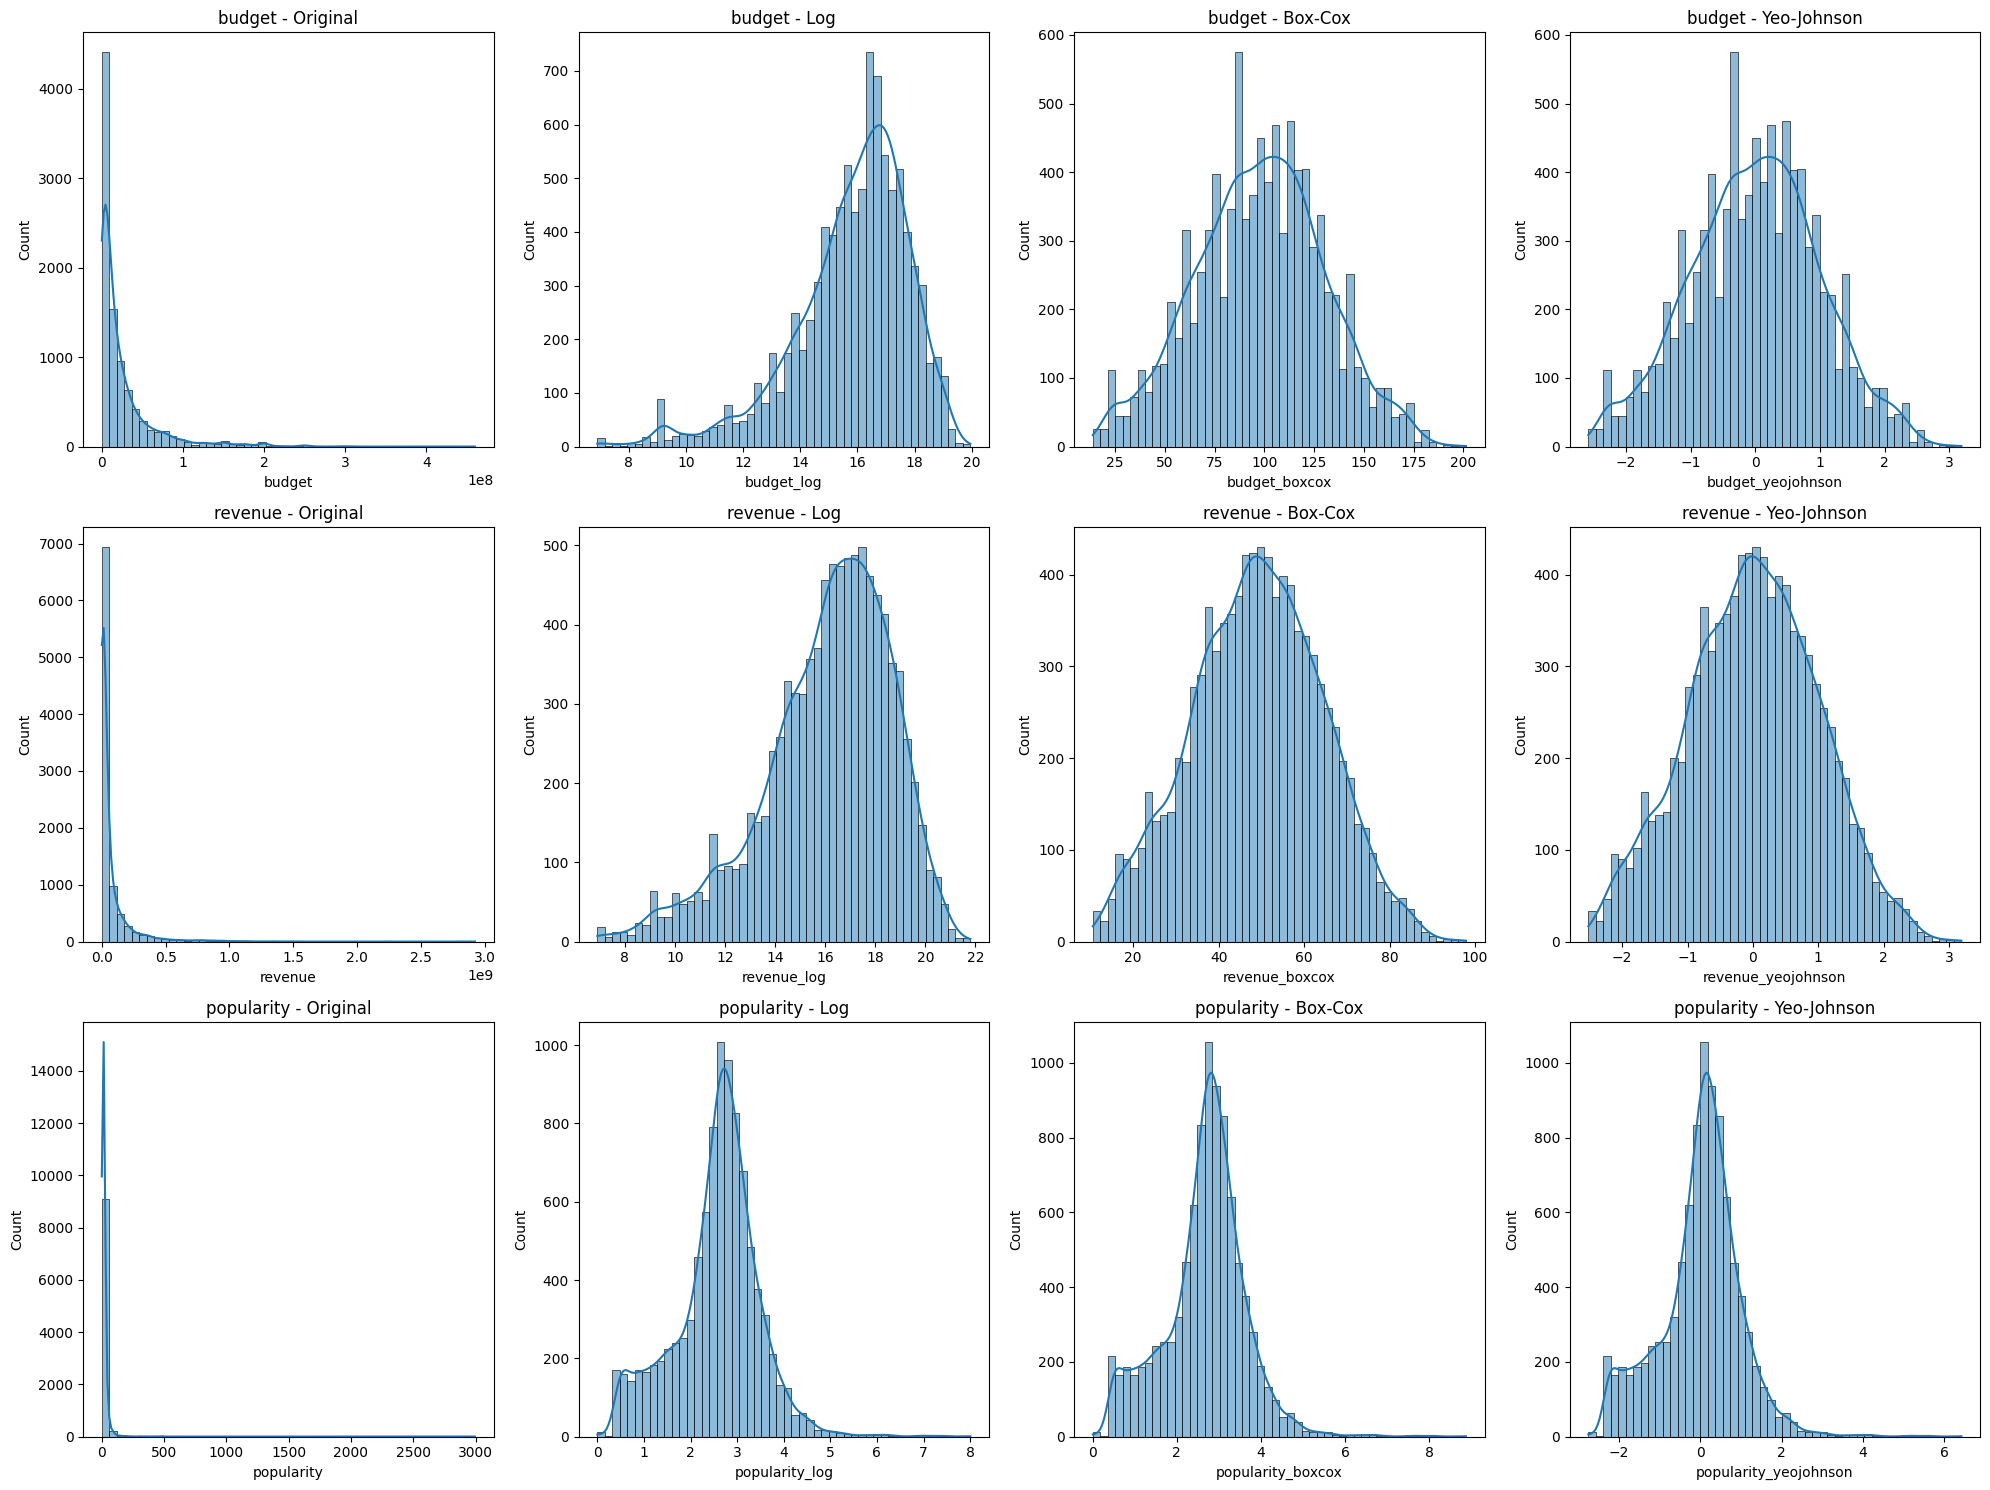

In [ ]:
# Comparación de transformaciones estadísticas
variables = [
    'budget',
    'revenue',
    'popularity'
]

transformaciones = [
    '',
    '_log',
    '_boxcox',
    '_yeojohnson'
]

titulos = [
    'Original',
    'Log',
    'Box-Cox',
    'Yeo-Johnson'
]

fig, axes = plt.subplots(
    3,
    4,
    figsize=(20,15)
)

for i, var in enumerate(variables):

    for j, trans in enumerate(transformaciones):

        columna = f'{var}{trans}'

        sns.histplot(
            df_transform[columna],
            bins=50,
            kde=True,
            ax=axes[i,j]
        )

        axes[i,j].set_title(
            f'{var} - {titulos[j]}'
        )

plt.tight_layout()

plt.show()

In [ ]:
# Evaluación de asimetría después de transformaciones
variables = [
    'budget',
    'revenue',
    'popularity'
]

transformaciones = [
    '',
    '_log',
    '_boxcox',
    '_yeojohnson'
]

tabla_skewness = pd.DataFrame()

for var in variables:

    for trans in transformaciones:

        columna = f'{var}{trans}'

        nombre = (
            f'{var}{trans}'
            if trans != ''
            else f'{var}_original'
        )

        tabla_skewness.loc[
            nombre,
            'Skewness'
        ] = df_transform[columna].skew()

# Redondear
tabla_skewness = tabla_skewness.round(2)

tabla_skewness

,Skewness
budget_original,3.26
budget_log,-1.15
budget_boxcox,-0.04
budget_yeojohnson,-0.04
revenue_original,5.75
revenue_log,-0.80
revenue_boxcox,-0.04
revenue_yeojohnson,-0.04
popularity_original,28.37
popularity_log,-0.10


Los métodos de escalamiento tradicionales mejoraron la comparabilidad de los datos, pero no resolvieron el problema de la asimetría. Por otro lado, las transformaciones matemáticas, especialmente Box-Cox y Yeo-Johnson, fueron más efectivas al producir distribuciones más equilibradas y estadísticamente manejables. Esto demuestra que transformar las variables era necesario para reducir el impacto de los outliers y obtener datos más adecuados para análisis y modelos posteriores.

In [ ]:
# Detección de valores atípicos mediante IQR
variables_iqr = [
    'budget',
    'revenue',
    'popularity'
]

tabla_iqr = pd.DataFrame()

for col in variables_iqr:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[col] < limite_inferior) |
        (df_clean[col] > limite_superior)
    ]

    porcentaje = (
        len(outliers) / len(df_clean)
    ) * 100

    tabla_iqr.loc[col, 'Q1'] = Q1
    tabla_iqr.loc[col, 'Q3'] = Q3
    tabla_iqr.loc[col, 'IQR'] = IQR
    tabla_iqr.loc[col, 'Limite_Inferior'] = limite_inferior
    tabla_iqr.loc[col, 'Limite_Superior'] = limite_superior
    tabla_iqr.loc[col, 'Cantidad_Outliers'] = len(outliers)
    tabla_iqr.loc[col, 'Porcentaje_Outliers'] = porcentaje

tabla_iqr.round(2)

,Q1,Q3,IQR,Limite_Inferior,Limite_Superior,Cantidad_Outliers,Porcentaje_Outliers
budget,2734475.00,30000000.00,27265525.00,-38163812.50,7.089829e+07,816.0,8.69
revenue,2400000.00,62783928.25,60383928.25,-88175892.38,1.533598e+08,1144.0,12.18
popularity,7.47,20.97,13.50,-12.78,4.122000e+01,642.0,6.83


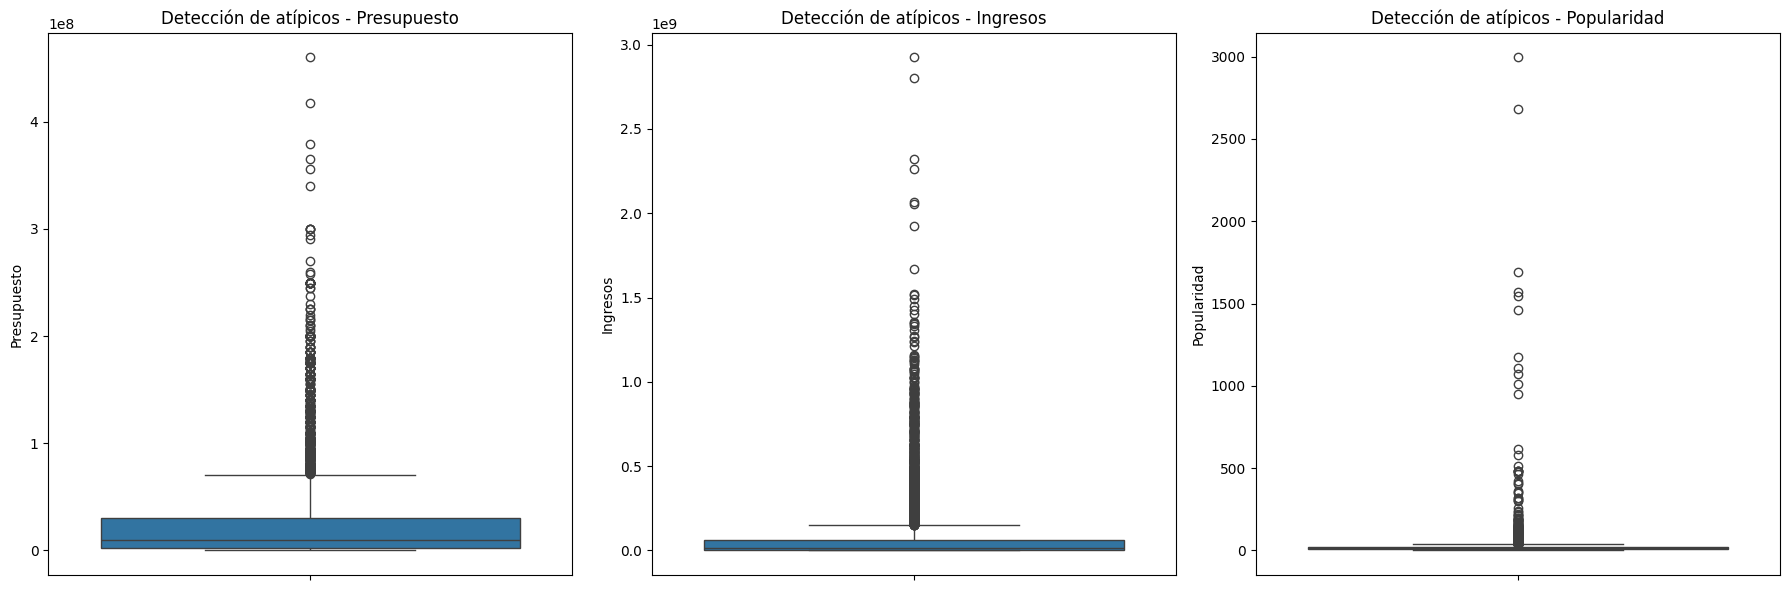

In [ ]:
# Visualización de valores atípicos con boxplots
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,6)
)

variables = [
    'budget',
    'revenue',
    'popularity'
]

titulos = [
    'Presupuesto',
    'Ingresos',
    'Popularidad'
]

for i, var in enumerate(variables):

    sns.boxplot(
        y=df_clean[var],
        ax=axes[i]
    )

    axes[i].set_title(
        f'Detección de atípicos - {titulos[i]}'
    )

    axes[i].set_ylabel(
        titulos[i]
    )

plt.tight_layout()

plt.show()

In [ ]:
# Cálculo de Z-Score sobre variables transformadas
variables_z = [
    'log_budget',
    'log_revenue',
    'log_popularity'
]

df_zscore = df_clean.copy()

for col in variables_z:

    df_zscore[f'z_{col}'] = zscore(
        df_zscore[col]
    )

In [ ]:
# Construcción de tabla resumen de outliers mediante Z-Score
tabla_zscore = pd.DataFrame()

for col in variables_z:

    outliers_z = df_zscore[
        abs(df_zscore[f'z_{col}']) > 3
    ]

    porcentaje = (
        len(outliers_z) / len(df_zscore)
    ) * 100

    tabla_zscore.loc[col, 'Cantidad_Outliers'] = (
        len(outliers_z)
    )

    tabla_zscore.loc[col, 'Porcentaje_Outliers'] = (
        porcentaje
    )

tabla_zscore.round(2)

,Cantidad_Outliers,Porcentaje_Outliers
log_budget,182.0,1.94
log_revenue,71.0,0.76
log_popularity,39.0,0.42


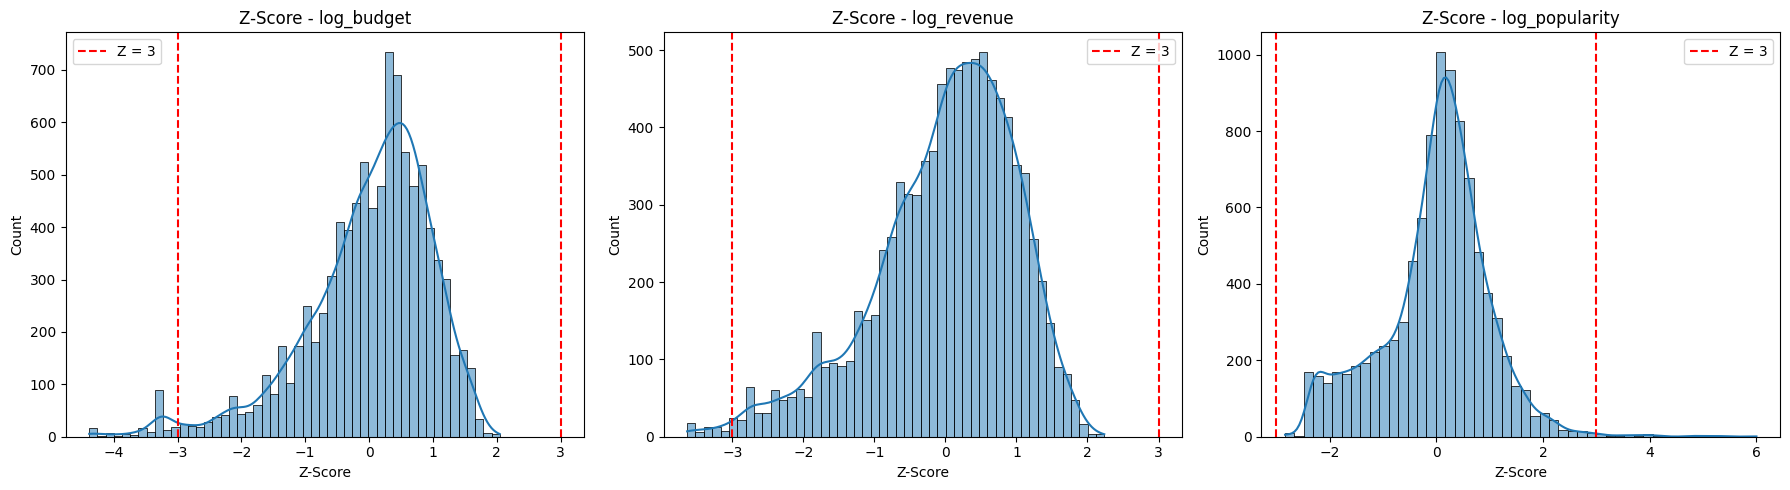

In [ ]:
# Visualización de distribuciones Z-Score
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

for i, col in enumerate(variables_z):

    sns.histplot(
        df_zscore[f'z_{col}'],
        bins=50,
        kde=True,
        ax=axes[i]
    )

    axes[i].axvline(
        3,
        color='red',
        linestyle='--',
        label='Z = 3'
    )

    axes[i].axvline(
        -3,
        color='red',
        linestyle='--'
    )

    axes[i].set_title(
        f'Z-Score - {col}'
    )

    axes[i].set_xlabel(
        'Z-Score'
    )

    axes[i].legend()

plt.tight_layout()

plt.show()

In [ ]:
# Calcular Z-Score
df_clean['z_budget'] = zscore(df_clean['log_budget'])
df_clean['z_revenue'] = zscore(df_clean['log_revenue'])
df_clean['z_popularity'] = zscore(df_clean['log_popularity'])

# Detectar outliers
df_clean['outlier_budget'] = (
    np.abs(df_clean['z_budget']) > 3
)

df_clean['outlier_revenue'] = (
    np.abs(df_clean['z_revenue']) > 3
)

df_clean['outlier_popularity'] = (
    np.abs(df_clean['z_popularity']) > 3
)

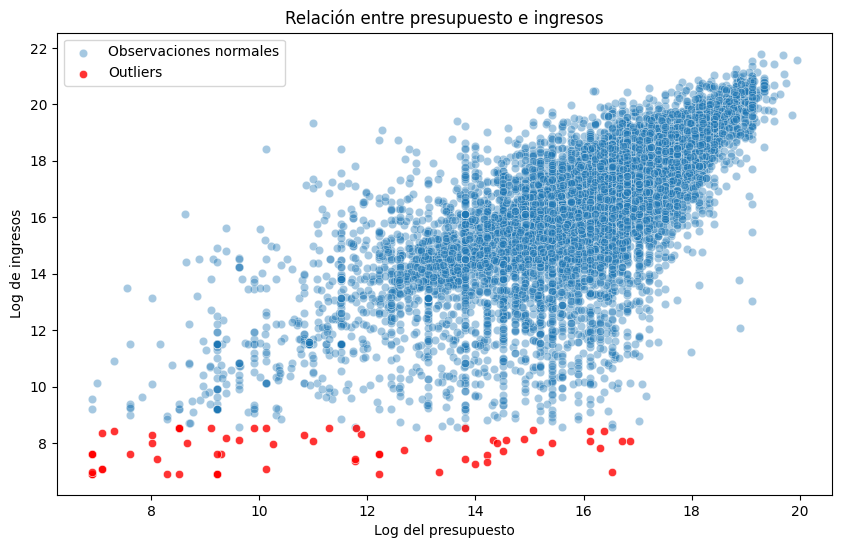

In [ ]:
# Relación entre presupuesto e ingresos
plt.figure(figsize=(10,6))

# Películas normales
sns.scatterplot(
    data=df_clean[
        ~df_clean['outlier_revenue']
    ],
    x='log_budget',
    y='log_revenue',
    alpha=0.4,
    label='Observaciones normales'
)

# Outliers
sns.scatterplot(
    data=df_clean[
        df_clean['outlier_revenue']
    ],
    x='log_budget',
    y='log_revenue',
    color='red',
    alpha=0.8,
    label='Outliers'
)

plt.title(
    'Relación entre presupuesto e ingresos'
)

plt.xlabel('Log del presupuesto')

plt.ylabel('Log de ingresos')

plt.legend()

plt.show()

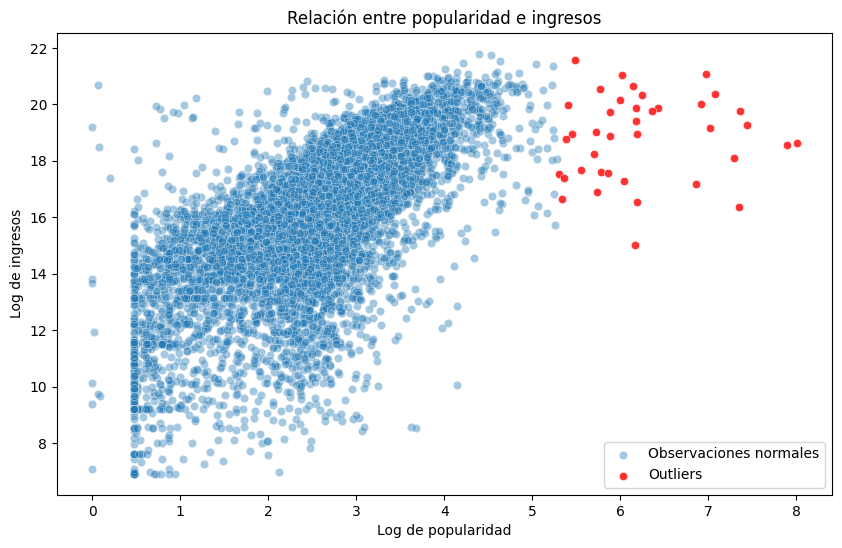

In [ ]:
# Relación entre popularidad e ingresos
plt.figure(figsize=(10,6))

# Observaciones normales
sns.scatterplot(
    data=df_clean[
        ~df_clean['outlier_popularity']
    ],
    x='log_popularity',
    y='log_revenue',
    alpha=0.4,
    label='Observaciones normales'
)

# Outliers
sns.scatterplot(
    data=df_clean[
        df_clean['outlier_popularity']
    ],
    x='log_popularity',
    y='log_revenue',
    color='red',
    alpha=0.8,
    label='Outliers'
)

plt.title(
    'Relación entre popularidad e ingresos'
)

plt.xlabel('Log de popularidad')

plt.ylabel('Log de ingresos')

plt.legend()

plt.show()

In [ ]:
# Conteo total de observaciones atípicas
print(
    "Outliers budget:",
    df_clean['outlier_budget'].sum()
)

print(
    "Outliers revenue:",
    df_clean['outlier_revenue'].sum()
)

print(
    "Outliers popularity:",
    df_clean['outlier_popularity'].sum()
)

Outliers budget: 182
Outliers revenue: 71
Outliers popularity: 39


In [ ]:
# Identificación de películas extremas
outliers_extremos = df_clean[
    df_clean['outlier_revenue']
][[
    'title',
    'budget',
    'revenue',
    'popularity',
    'vote_average'
]].sort_values(
    by='revenue',
    ascending=False
)

outliers_extremos.head(10)

,title,budget,revenue,popularity,vote_average
12468,Monster High: The Movie,1000000,5000,38.734,7.0
256142,Per l'amor di Dio,80000,5000,0.600,10.0
212395,Pioneering Nevada's Basin and Range Trail,5000,5000,0.600,7.0
143884,Hot Naked Sex & the City,5000,5000,0.969,6.3
140347,Hardcore,5000,5000,1.418,3.6
62292,Newlyweds,9000,5000,3.296,6.0
32144,"Sí, Mi Amor",5000,5000,3.729,7.0
314020,Kropemann,25000,5000,0.600,0.0
437987,The Green Force,132925,5000,0.671,0.0
266221,Green Eyes,20000,5000,0.991,10.0


In [ ]:
# Variables para clustering
variables_cluster = [
    'log_budget',
    'log_revenue',
    'log_popularity'
]

# DataFrame para clustering
df_cluster = df_clean[variables_cluster].copy()

# Escalamiento
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_cluster)

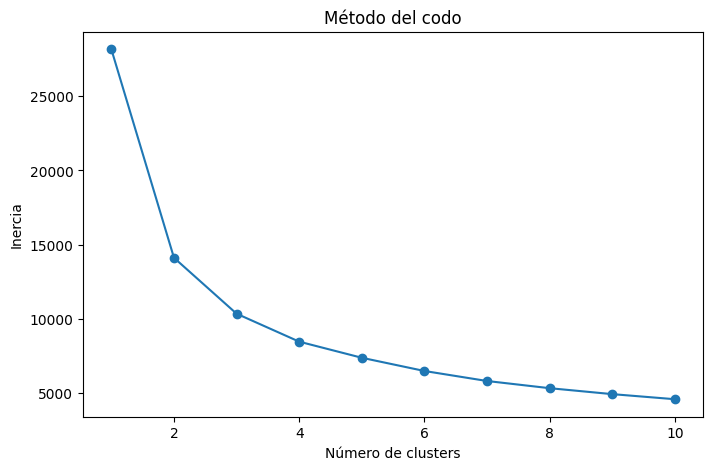

In [ ]:
# Método del codo para selección de clusters
inertia = []

K = range(1, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

# Gráfica
plt.figure(figsize=(8,5))

plt.plot(
    K,
    inertia,
    marker='o'
)

plt.title('Método del codo')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')

plt.show()

In [ ]:
# Aplicación del algoritmo K-Means
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_clean['cluster'] = kmeans.fit_predict(X_scaled)

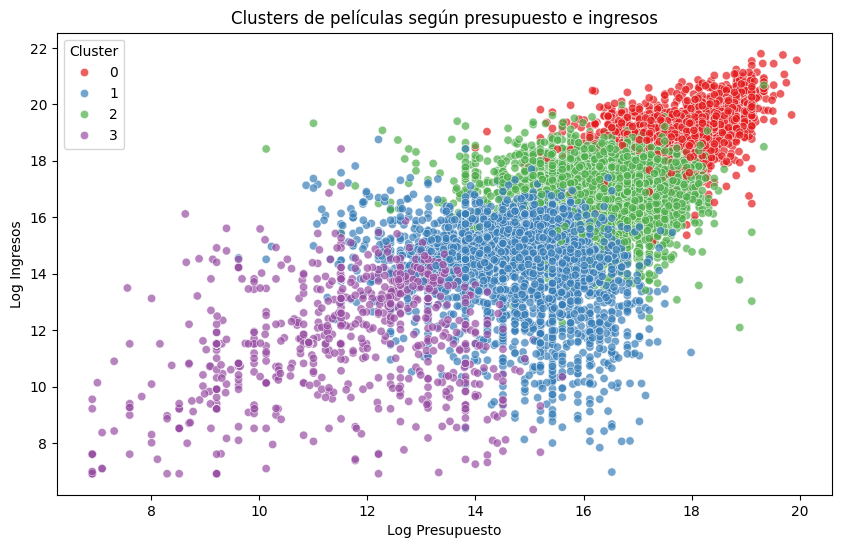

In [ ]:
# Visualización de clusters: presupuesto vs ingresos
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x='log_budget',
    y='log_revenue',
    hue='cluster',
    palette='Set1',
    alpha=0.7
)

plt.title('Clusters de películas según presupuesto e ingresos')
plt.xlabel('Log Presupuesto')
plt.ylabel('Log Ingresos')

plt.legend(title='Cluster')

plt.show()

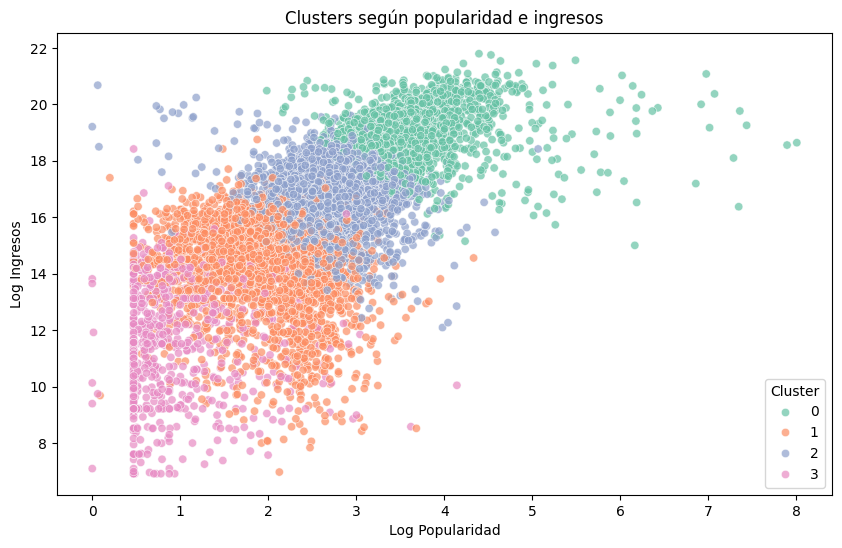

In [ ]:
# Visualización de clusters: popularidad vs ingresos
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x='log_popularity',
    y='log_revenue',
    hue='cluster',
    palette='Set2',
    alpha=0.7
)

plt.title('Clusters según popularidad e ingresos')
plt.xlabel('Log Popularidad')
plt.ylabel('Log Ingresos')

plt.legend(title='Cluster')

plt.show()

In [ ]:
# Resumen estadístico por cluster
cluster_summary = df_clean.groupby('cluster')[[
    'budget',
    'revenue',
    'popularity'
]].mean().round(2)

cluster_summary

,budget,revenue,popularity
cluster,,,
0,70286582.29,2.424757e+08,49.68
1,4330298.50,3.551499e+06,7.66
2,18188174.30,3.275280e+07,15.63
3,326895.78,6.478896e+05,2.31


El análisis de datos atípicos evidenció la presencia de valores extremos principalmente en las variables de presupuesto e ingresos, lo cual resulta coherente con la naturaleza altamente desigual de la industria cinematográfica, donde unas pocas producciones concentran gran parte de la inversión y recaudación global. Mediante el método IQR se identificó una proporción considerable de observaciones extremas, especialmente en revenue (12.32%). Sin embargo, tras aplicar transformaciones sobre las variables sesgadas y utilizar Z-Score sobre las versiones transformadas, la cantidad de outliers disminuyó notablemente, indicando que gran parte de los extremos iniciales estaban asociados a la asimetría de las distribuciones y no necesariamente a inconsistencias en los datos. Adicionalmente, los análisis multivariados mediante scatterplots y clustering con K-Means permitieron identificar grupos diferenciados de películas según su comportamiento financiero y de popularidad, así como detectar casos particulares con comportamientos anómalos respecto a su presupuesto o rendimiento en taquilla.

In [ ]:
# Identificación de valores faltantes
missing = pd.DataFrame({
    'Missing': df_clean.isnull().sum(),
    'Porcentaje': (
        df_clean.isnull().mean() * 100
    )
})

missing = missing[
    missing['Missing'] > 0
].sort_values(
    by='Porcentaje',
    ascending=False
)

missing.round(2)

,Missing,Porcentaje
homepage,6240,66.43
tagline,1790,19.05
keywords,883,9.40
backdrop_path,450,4.79
production_companies,291,3.10
production_countries,169,1.80
writers,115,1.22
spoken_languages,62,0.66
poster_path,54,0.57
genres,29,0.31


#Variables MNAR:
- homepage
- tagline
- keywords

Estas variables presentan porcentajes elevados de datos faltantes y su ausencia no parece aleatoria. En muchos casos, las películas independientes, antiguas o de bajo presupuesto no cuentan con una web oficial, eslogan comercial o palabras clave registradas. Esto sugiere que la ausencia de información está relacionada con características propias de la película, especialmente su nivel de producción y comercialización.

#Variables MAR
- production_companies
- production_countries
- spoken_languages
- writers
- cast
- directors
- genres

Estas variables presentan porcentajes bajos o moderados de valores faltantes. En estos casos, la ausencia de información podría depender de factores externos como antigüedad de la película, calidad del registro, fuente y/o diferencias entre plataformas de metadatos. La ausencia no parece depender directamente del valor de la variable en sí, sino de otras características observables del conjunto de datos.

#Variables MCAR
- release_date
- release_year
- overview
- poster_path
- backdrop_path

presentan porcentajes muy bajos de datos faltantes. En estos casos, la ausencia parece ser debido a errores de captura, problemas de sincronización entre bases de datos y/o registros incompletos sin un patrón evidente. Debido a esto, se puede considerar que los valores faltantes ocurren de manera aleatoria.

In [ ]:
df_clean.to_csv(
    'Base_de_datos_procesada.csv',
    index=False
)

In [ ]:
from google.colab import files

files.download('Base_de_datos_procesada.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>